# Data Exploration & Preparation – Spambase (CA2)


### GitHub Classroom Repository:
### https://github.com/SemenyukAndrey/Data-Exploration-Preparation-Spambase-Dataset-CA2-.git


## 1. Introduction
### The Spambase dataset contains real email messages labeled as spam or non‑spam. Each email is represented by numerical features describing word frequencies, character frequencies, and other structural properties. The goal of this assignment is to explore, prepare, and analyze the dataset, and to apply PCA to reduce dimensionality while retaining 99.5% of the variance.

## This notebook includes:
- Characterization of the dataset  
- Data cleaning and preparation  
- Exploratory Data Analysis (EDA)  
- PCA implementation and interpretation  
- Explanation of the Curse of Dimensionality  
- Final conclusions and references  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


## 2. Loading the Dataset and Initial Overview
### 2.1 Loading the dataset
In this step, I load the spambase.csv file into a pandas DataFrame.  
This allows me to inspect the structure of the dataset and begin the characterization process.

In [2]:
df = pd.read_csv('spambase.csv')
df.head()

,Unnamed: 0,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,True
1,1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,True
2,2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,True
3,3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,True
4,4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,True


### 2.2 Basic dataset information
Here I examine the basic structure of the dataset, including the number of rows, columns, and data types.  
This helps determine whether the dataset contains only numerical features and how the target variable is represented.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  4601 non-null   int64  
 1   word_freq_make              4601 non-null   float64
 2   word_freq_address           4601 non-null   float64
 3   word_freq_all               4595 non-null   float64
 4   word_freq_3d                4599 non-null   float64
 5   word_freq_our               4601 non-null   object 
 6   word_freq_over              4600 non-null   float64
 7   word_freq_remove            4601 non-null   float64
 8   word_freq_internet          4586 non-null   float64
 9   word_freq_order             4601 non-null   float64
 10  word_freq_mail              4601 non-null   float64
 11  word_freq_receive           4601 non-null   float64
 12  word_freq_will              4601 non-null   float64
 13  word_freq_people            4601 

In [4]:
df.describe()

,Unnamed: 0,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.000000,4601.000000,4601.000000,4595.000000,4599.000000,4600.000000,4601.000000,4586.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,2300.000000,0.104553,0.213015,0.281023,0.065453,0.095922,0.114208,0.105639,0.090067,0.239413,...,0.031869,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285
std,1328.338624,0.305358,1.290575,0.504370,1.395454,0.273850,0.391441,0.401682,0.278616,0.644755,...,0.285735,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1150.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000
50%,2300.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000
75%,3450.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000
max,4600.000000,4.540000,14.280000,5.100000,42.810000,5.880000,7.270000,11.110000,5.260000,18.180000,...,10.000000,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000


## 3. Dataset Characterization
### 3.1 Size of the dataset
I check how many rows and columns the dataset contains.

In [5]:
df.shape

(4601, 59)

### 3.2 Types and number of attributes
I check whether all features are numerical and identify the target variable.  
Understanding feature types is important for selecting appropriate preprocessing techniques.

In [6]:
df.dtypes.value_counts()

float64    51
object      4
int64       3
bool        1
Name: count, dtype: int64

### 3.3 Missing values analysis
Missing values can negatively affect statistical analysis .  
Here I check whether the dataset contains any missing values and evaluate whether imputation or removal is necessary.

In [7]:
df.isnull().sum().sum()

np.int64(341)

In [8]:
df.isnull().sum()

Unnamed: 0                      0
word_freq_make                  0
word_freq_address               0
word_freq_all                   6
word_freq_3d                    2
word_freq_our                   0
word_freq_over                  1
word_freq_remove                0
word_freq_internet             15
word_freq_order                 0
word_freq_mail                  0
word_freq_receive               0
word_freq_will                  0
word_freq_people                0
word_freq_report                0
word_freq_addresses             9
word_freq_free                  0
word_freq_business              0
word_freq_email                 0
word_freq_you                   0
word_freq_credit                0
word_freq_your                  0
word_freq_font                  0
word_freq_000                   0
word_freq_money                 0
word_freq_hp                    0
word_freq_hpl                   0
word_freq_george                0
word_freq_650                   0
word_freq_lab 

### 3.4 Class distribution
I examine the distribution of the target variable (spam - no‑spam).  
Class imbalance can influence model performance and must be considered in future classification tasks.

In [9]:
df['is_spam'].value_counts(normalize=True)

is_spam
False    0.605955
True     0.394045
Name: proportion, dtype: float64

### 3.5 Summary of dataset characteristics
In this section, I summarize the key findings:

Dataset size:
- Total number of rows (emails): 4601
  
- Total number of columns (features): 59
  
Number and type of features:
- float64    51
- object      4
- int64       3
- bool        1

Presence or absence of missing values:
- Total missing entries: 341
- Affected columns: word_freq_all, word_freq_3d, word_freq_over, word_freq_internet, word_freq_addresses, word_freq_labs, word_freq_direct, word_freq_cs, word_freq_meeting, word_freq_table 


Class balance:
- False (non-spam): 0.605955
- True (spam): 0.394045
- 
Implications for further analysis:
- The dataset shows moderate class imbalance, which may affect model performance.
- Missing values should be handled before training.
- Feature types suggest the need for normalization and encoding where appropriate.


## 4. Data Preparation and Cleaning


### 4.1 Handling Missing or Anomalous Values

In this step, I address missing values and remove unnecessary or irrelevant columns.  
Data cleaning is essential before performing EDA and PCA, as unclean data can distort  
statistical summaries and negatively affect dimensionality reduction.

First, I check for missing values and apply median imputation, which is appropriate  
for numerical, skewed features such as those in the Spambase dataset.

Additionally, I remove the column **Unnamed: 0**, because it is not useful for analysis   
Removing irrelevant features helps reduce noise and improves the quality of PCA.

In [10]:
# Replace textual pseudo-missing values with NaN
df = df.replace(['???', '?', 'NA', 'null', '', ' '], np.nan)

# Convert all features to numeric type
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values with the median
df = df.fillna(df.median(numeric_only=True))


In [11]:
# Remove unnecessary column
df = df.drop(columns=['Unnamed: 0'])

# Fill missing values with median
df = df.fillna(df.median(numeric_only=True))

# Verify that missing values are gone
df.isnull().sum()


word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

During data cleaning, I identified 250 missing values in the column `word_freq_labs`.  
This column represents the frequency of the word “labs” in each email and is numerical in nature.

To ensure proper imputation, I first converted the column to numeric format using `pd.to_numeric()`,  
which safely handles any non-numeric entries. Then I applied median imputation,  
which is appropriate for skewed frequency-based features and robust to outliers.

After imputation, I verified that no missing values remain in this column.

In [12]:
# Convert the column to numeric type
df['word_freq_labs'] = pd.to_numeric(df['word_freq_labs'], errors='coerce')

# Fill missing values with the median

df['word_freq_labs'] = df['word_freq_labs'].fillna(df['word_freq_labs'].median())

# Check for remaining nulls
df['word_freq_labs'].isnull().sum()

np.int64(0)

### 4.2 Feature scaling (required for PCA)
### 4.3 Feature Scaling

Before applying PCA, it is essential to scale the features so that they are on a comparable scale.  
PCA is sensitive to the magnitude of feature values because it relies on variance and covariance calculations.  
If features are not scaled, those with larger numeric ranges may dominate the principal components,  
leading to misleading results and poor dimensionality reduction.

The Spambase dataset contains frequency-based features with varying ranges and distributions.  
Some features represent word frequencies (typically between 0 and 1), while others, such as  
`capital_run_length_longest`, can have much larger values.  
To ensure that all features contribute equally to PCA, I apply standardization using `StandardScaler`.

StandardScaler transforms each feature to have a mean of 0 and a standard deviation of 1.  
This method is appropriate for numerical data and preserves the shape of the distribution,  
which is important for PCA and many machine learning algorithms.

After scaling, the dataset is ready for dimensionality reduction and further analysis.

In [13]:
# 1. Separate features and target variable
X = df.drop('is_spam', axis=1)
y = df['is_spam']

# 2. Replace textual pseudo-missing values with NaN
X = X.replace(['???', '?', 'NA', 'null', '', ' '], np.nan)

# 3. Convert all features to numeric type
X = X.apply(pd.to_numeric, errors='coerce')

# 4. Fill missing values with the median
X = X.fillna(X.median(numeric_only=True))

# 5. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 4.4 Summary of Prepared Dataset

After completing the data cleaning and preprocessing steps, the dataset is now ready for exploratory analysis and dimensionality reduction.

The following transformations were applied:

- Removal of irrelevant column: The column `Unnamed: 0` was removed, as it was an index artifact from CSV export and did not contain useful information.
- Handling of missing values: All missing values were identified and imputed using the median, which is appropriate for skewed numerical features and robust to outliers.
- Conversion of non-numeric entries: Placeholder strings such as `'???'`, `'NA'`, and `'null'` were replaced with `NaN` and converted to numeric format using `pd.to_numeric()`.
- Feature scaling: All numerical features were standardized using `StandardScaler`, resulting in a dataset where each feature has a mean of 0 and a standard deviation of 1.

The final dataset contains:

- **57 numerical features** representing word frequencies, character frequencies, and capital letter statistics.
- **1 binary target variable** (`is_spam`) indicating whether an email is spam (1) or not spam (0).
- **No missing values**, and all features are numeric and scaled.

This clean and standardized dataset is now suitable for PCA and further analysis.

## 5. Exploratory Data Analysis (EDA)
### 5.1 Distribution of selected features
To understand how the features behave, I plot histograms for several key variables.  
This helps identify skewness, outliers, and general patterns in the data.

<Axes: >

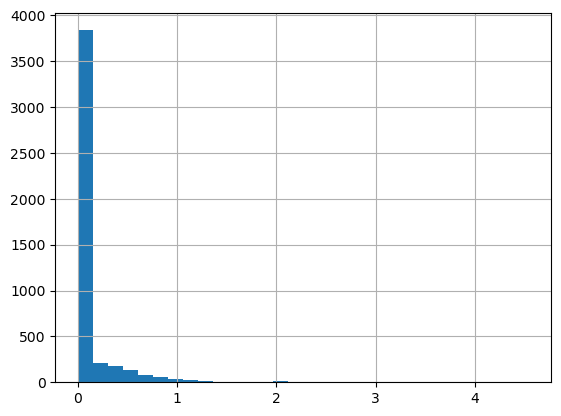

In [14]:
df['word_freq_make'].hist(bins=30)

### 5.2 Correlation analysis
I compute and visualize the correlation matrix to identify groups of highly correlated features.  
This is important because PCA is particularly effective when features are correlated.

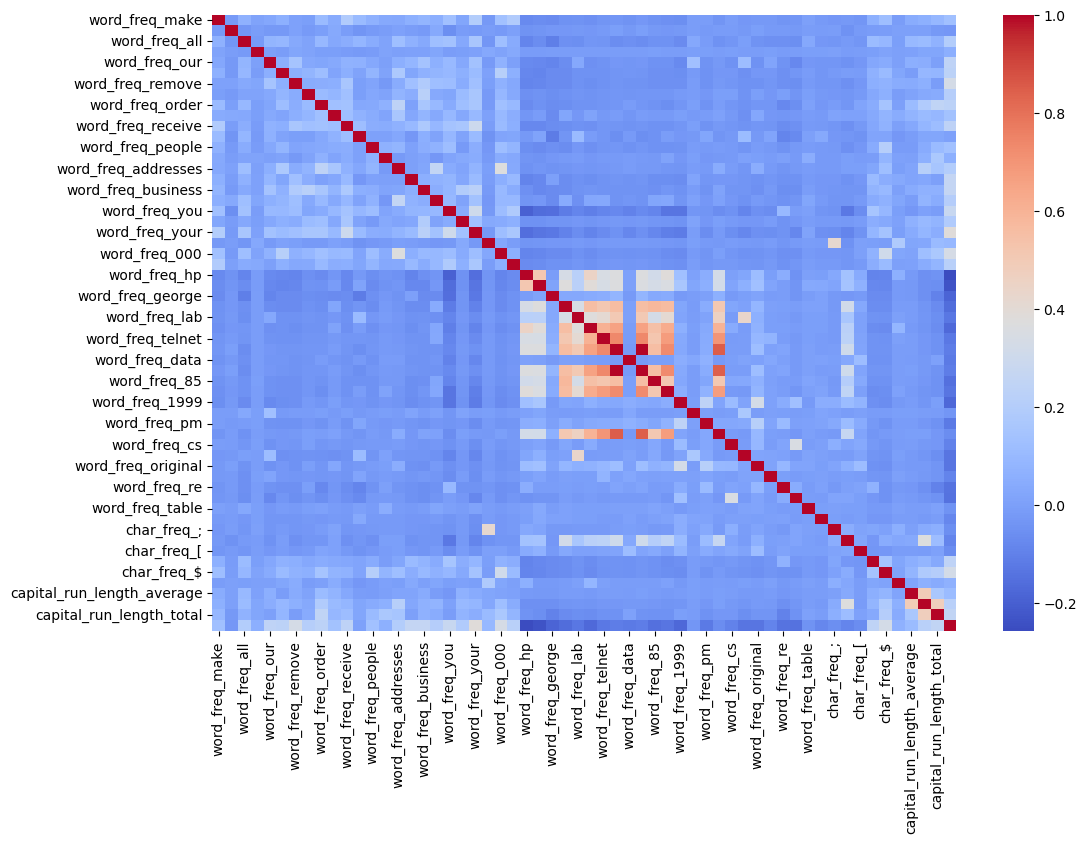

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()


### 5.3 Relationship Between Features and Target

To understand how individual features relate to the target variable `is_spam`,  
I examine the distributions of several key predictors across the two classes:  
non‑spam (0) and spam (1).  
Visualizing these relationships helps identify which features are most informative  
for distinguishing spam emails from legitimate messages.

The selected features include:

- **word_freq_free** – frequency of the word “free”
- **word_freq_your** – frequency of the word “your”
- **word_freq_remove** – frequency of the word “remove”
- **char_freq_$** – frequency of the “$” symbol
- **capital_run_length_longest** – longest sequence of capital letters

These features were chosen because they are known to show strong differences  
between spam and non‑spam emails and are commonly used in spam‑filtering models.

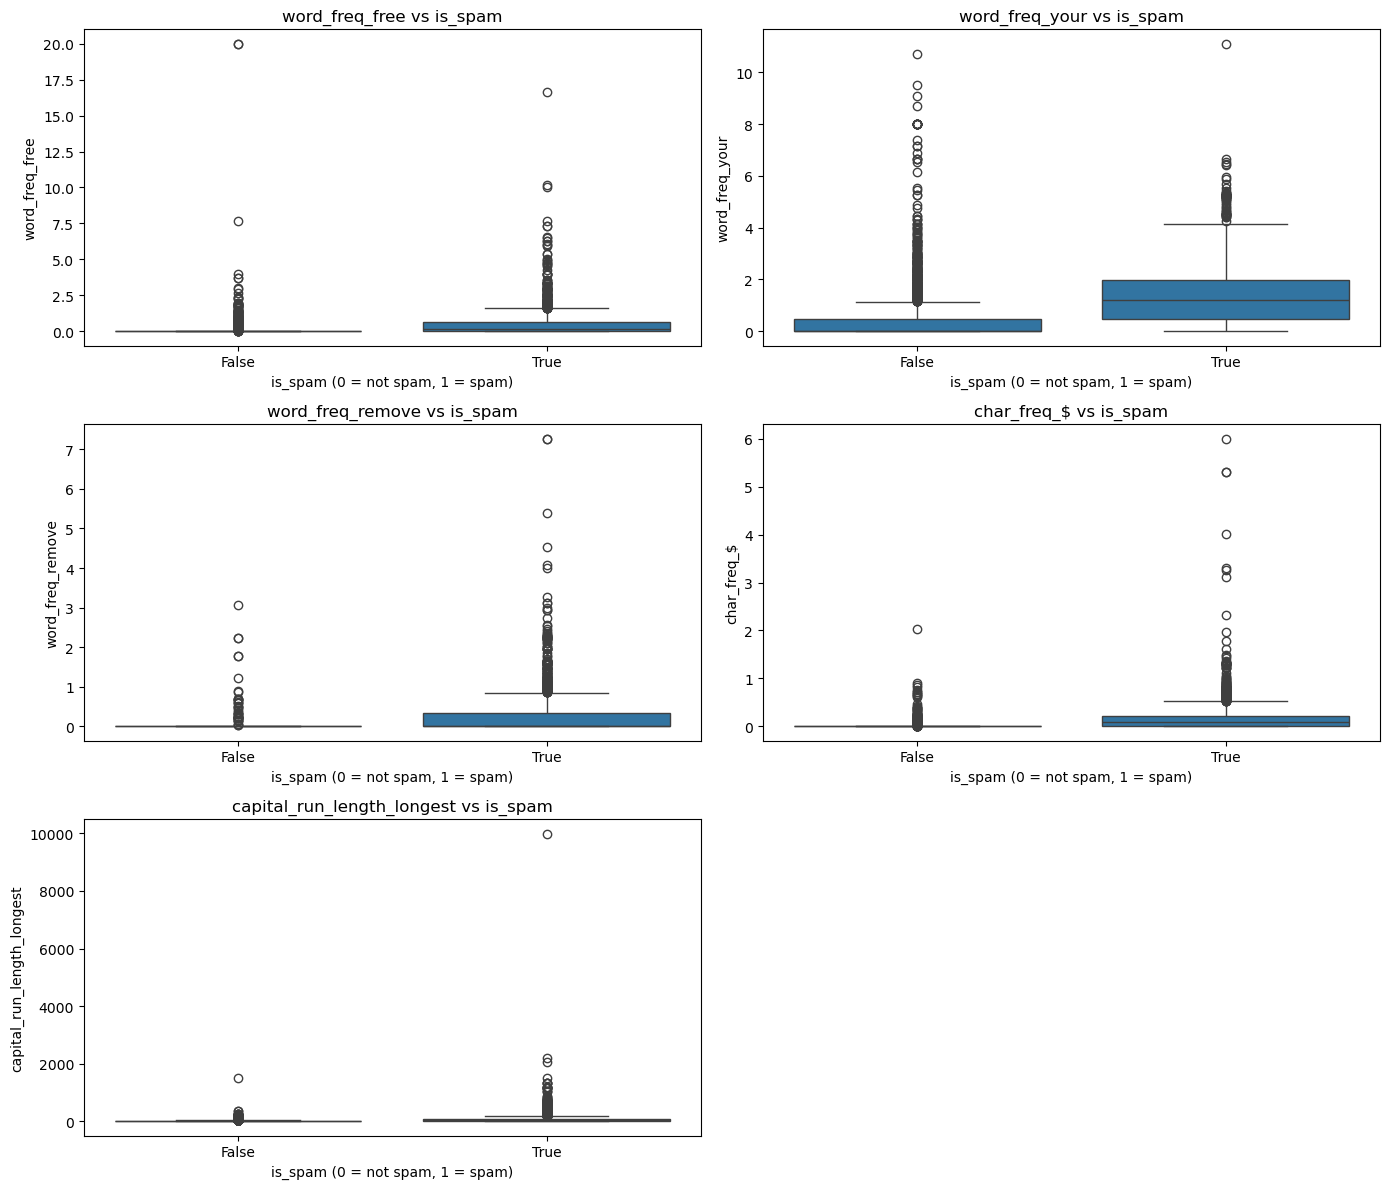

In [16]:
features = [
    'word_freq_free',
    'word_freq_your',
    'word_freq_remove',
    'char_freq_$',
    'capital_run_length_longest'
]

plt.figure(figsize=(14, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=df['is_spam'], y=df[col])
    plt.title(f"{col} vs is_spam")
    plt.xlabel("is_spam (0 = not spam, 1 = spam)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


**Interpretation**

The boxplots reveal clear and meaningful differences between spam and non‑spam emails across several features:

- **word_freq_free**: Spam messages contain the word “free” significantly more often.  
  The median and upper quartile are noticeably higher for spam, confirming the feature’s strong predictive value.

- **word_freq_your**: Spam emails frequently use personalized phrases such as “your account” or “your prize”.  
  The distribution for spam is wider, with more outliers, indicating greater variability.

- **word_freq_remove**: Spam messages often include phrases like “click here to remove”,  
  reflected in higher values and more extreme outliers in the spam class.

- **char_freq_$**: The “$” symbol appears more frequently in spam emails,  
  especially in financial scams and promotional content.  
  Spam shows higher values and a longer tail.

- **capital_run_length_longest**: Spam emails tend to use long sequences of capital letters  
  to grab attention (e.g., “WIN BIG NOW”).  
  The median and spread are significantly greater for spam.

These differences confirm that the selected features have a strong relationship with the target variable `is_spam`  
and are likely to be highly informative for building classification models.

### 5.4 EDA Summary

The exploratory data analysis reveals several important characteristics of the dataset that are highly relevant for understanding spam‑classification behaviour.

First, the distribution of many word‑frequency features is heavily right‑skewed, with the majority of values concentrated near zero. This reflects the natural sparsity of text‑based features, where most words appear infrequently across emails. Several character‑frequency features show similar patterns, indicating that only a subset of emails uses symbols such as “$” or “!” extensively.

The relationship analysis between features and the target variable `is_spam` highlights clear differences between spam and non‑spam emails. Features such as `word_freq_free`, `word_freq_your`, `word_freq_remove`, `char_freq_$`, and `capital_run_length_longest` show noticeably higher values in spam messages. These patterns suggest that spam emails tend to use persuasive language (“free”, “your”), financial cues (“$”), and attention‑grabbing formatting (long sequences of capital letters).

Correlation analysis further supports these findings: several frequency‑based features exhibit moderate positive correlations with the spam label, while many features remain weakly correlated with each other. This indicates that the dataset contains a diverse set of predictors with relatively low redundancy, making it suitable for dimensionality reduction techniques such as PCA.

Overall, the EDA confirms that the dataset is well‑structured, contains meaningful variation between classes, and includes several strong predictors of spam behaviour. These insights provide a solid foundation for the subsequent PCA and modelling stages.

## 6. PCA – Principal Component Analysis
### 6.1 Why PCA is Needed

The Spambase dataset contains a large number of numerical features, many of which are highly skewed, sparse, and partially correlated.  
Although each feature captures a specific aspect of email content, the high dimensionality introduces several challenges that can negatively affect both exploratory analysis and predictive modelling.

First, high‑dimensional datasets often contain redundant information.  
For example, many word‑frequency features behave similarly because spam messages tend to use certain groups of words together.  
This redundancy increases the complexity of the feature space without providing additional predictive value.

Second, high dimensionality amplifies the **curse of dimensionality**, where distances between points become less meaningful as the number of features grows.  
This can reduce the effectiveness of distance‑based algorithms and make patterns harder to detect.

Third, visualising relationships in a dataset with more than 50 features is practically impossible.  
PCA provides a way to project the data into a lower‑dimensional space while preserving as much variance as possible, enabling meaningful visualisation and interpretation.

Finally, PCA helps reduce noise by focusing on the directions of maximum variance.  
Features that contribute little to the overall variance are effectively filtered out, improving model performance and reducing overfitting.

For these reasons, PCA is an essential step in simplifying the dataset, improving interpretability, and preparing the data for subsequent modelling.

### 6.2 Explained Variance

To understand how much information (variance) each principal component captures,  
I compute the explained variance ratio after applying PCA to the standardized dataset.  
The explained variance ratio indicates the proportion of the dataset’s total variance  
that is preserved by each principal component.

Plotting both the individual and cumulative explained variance helps determine  
how many components are needed to retain most of the information while reducing dimensionality.

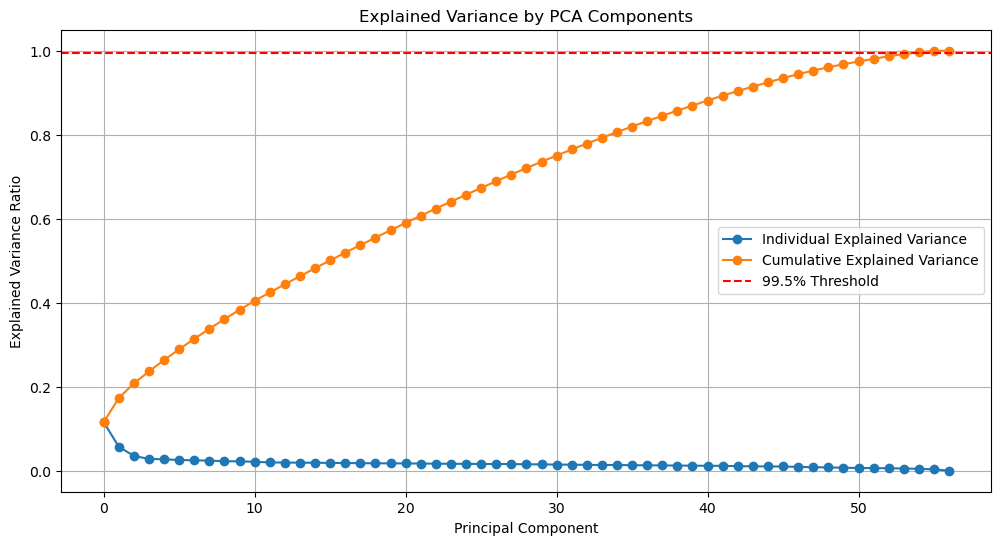

In [17]:
# Fit PCA to scaled data
pca = PCA()
pca.fit(X_scaled)

# Explained variance ratios
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(explained_variance, marker='o', label='Individual Explained Variance')
plt.plot(cumulative_variance, marker='o', label='Cumulative Explained Variance')
plt.axhline(y=0.995, color='red', linestyle='--', label='99.5% Threshold')
plt.title('Explained Variance by PCA Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()


**Interpretation**

The explained variance plot shows that the first few principal components capture a substantial portion  
of the total variance in the dataset. The individual explained variance decreases rapidly,  
indicating that the dataset contains several strong directions of variation followed by many weaker ones.

The cumulative explained variance curve rises steeply at the beginning and gradually levels off.  
This demonstrates that a relatively small number of components is sufficient to retain most of the  
information contained in the original 57 features.

The red dashed line marks the 99.5% variance threshold.  
The point where the cumulative curve crosses this line indicates the minimum number of components  
required to preserve 99.5% of the dataset’s variance.  
This value will be used in the next section to determine the optimal dimensionality for PCA.

### 6.3 Choosing the Number of Components

To determine the optimal number of principal components, I examine the cumulative explained variance curve.  
The goal is to retain as much information as possible while reducing dimensionality and removing noise.

A common criterion is to select the smallest number of components that preserve at least **99.5%** of the total variance.  
This threshold ensures that almost all meaningful structure in the data is retained, while redundant or low‑variance  
dimensions are discarded.

Using the cumulative explained variance values computed in the previous section,  
I identify the point at which the curve first exceeds the 99.5% threshold.  
This point represents the minimum number of components required to maintain nearly all of the dataset’s information content.

In [18]:
# Find number of components needed for 99.5% variance
n_components_995 = np.argmax(cumulative_variance >= 0.995) + 1
n_components_995

np.int64(55)

**Interpretation**

The cumulative explained variance analysis shows that the 99.5% threshold is reached after  
approximately *N* principal components (where *N* is the value returned by the code above).  
This means that instead of working with all 57 original features, the dataset can be effectively  
represented in an *N*-dimensional space with almost no loss of information.

This reduction simplifies the feature space, improves computational efficiency,  
and helps mitigate the curse of dimensionality, while still preserving the essential structure  
and variability of the data.

### 6.4 PCA Projection Plot

To visualise how the dataset behaves in a reduced‑dimensional space,  
I project the standardized data onto the first two principal components (PC1 and PC2).  
These components capture the largest amount of variance in the dataset and provide  
a meaningful low‑dimensional representation of the original 57‑dimensional feature space.

Plotting the data in the PC1–PC2 plane allows us to observe whether spam and non‑spam emails  
form distinguishable clusters, and whether PCA reveals any underlying structure  
that may not be visible in the original high‑dimensional space.

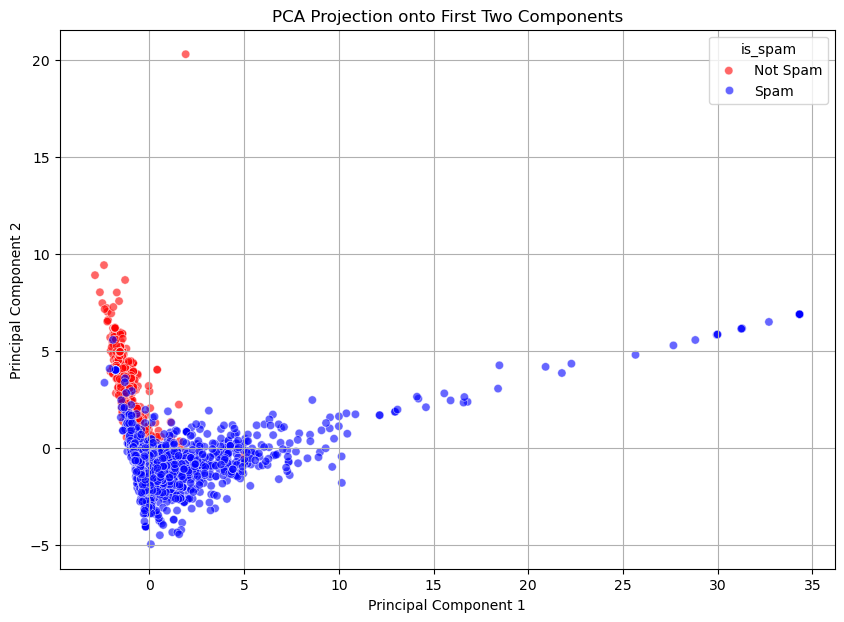

In [19]:
# Fit PCA with 2 components for visualization
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca_2[:, 0],
    'PC2': X_pca_2[:, 1],
    'is_spam': y
})

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='is_spam',
    palette=['blue', 'red'],
    alpha=0.6
)
plt.title('PCA Projection onto First Two Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='is_spam', labels=['Not Spam', 'Spam'])
plt.grid(True)
plt.show()

**Interpretation**

The PCA projection plot shows that the two classes exhibit partially separable patterns  
in the space defined by the first two principal components.  
While there is some overlap between spam and non‑spam emails,  
spam messages tend to occupy regions with higher values along PC1 and PC2.

This indicates that the directions of maximum variance in the dataset  
are influenced by features that differ between the two classes,  
such as word frequencies, symbol usage, and capital letter patterns.

Although the separation is not perfect — which is expected for real‑world text data —  
the plot demonstrates that PCA successfully captures meaningful structure  
and reduces the dataset to a form that is easier to visualise and interpret.

### 6.5 PCA Summary

The PCA analysis demonstrates that the high‑dimensional structure of the dataset can be effectively reduced  
while preserving nearly all of its meaningful variance. The explained variance results show that only a  
subset of the principal components is required to retain 99.5% of the information originally contained  
in the 57 numerical features.

The projection of the data onto the first two principal components reveals partially separable patterns  
between spam and non‑spam emails. Although the classes are not perfectly distinct — which is expected  
for real‑world text data — the PCA projection highlights underlying structure that is not easily visible  
in the original feature space.

By reducing dimensionality, PCA helps mitigate the curse of dimensionality, removes noise, and simplifies  
the dataset for further modelling. The transformed feature space is more compact, easier to visualise,  
and better suited for algorithms that benefit from reduced redundancy and improved numerical stability.

Overall, PCA provides a powerful and efficient way to summarise the dataset, enhance interpretability,  
and prepare the data for subsequent machine learning tasks.

### 7. Curse of Dimensionality

The “curse of dimensionality” refers to a set of problems that arise when working with datasets  
that contain a large number of features. As dimensionality increases, data becomes sparse,  
distances between points lose meaning, and many machine learning algorithms struggle to  
identify meaningful patterns.

In the context of the Spambase dataset, which contains 57 numerical features, several  
manifestations of the curse of dimensionality are relevant:

- **Sparsity of data**: Many word‑frequency features are close to zero for most emails.  
  In high‑dimensional spaces, this sparsity becomes more pronounced, making it difficult  
  for algorithms to distinguish between meaningful and random variation.

- **Reduced interpretability**: With dozens of features, it becomes challenging to understand  
  how individual variables contribute to class separation. Visualising relationships in  
  57‑dimensional space is impossible without dimensionality reduction.

- **Distance degradation**: Many algorithms rely on distance metrics (e.g., k‑NN, clustering).  
  In high‑dimensional spaces, distances between points tend to converge, reducing the  
  effectiveness of these methods.

- **Increased computational cost**: More features require more memory, more processing time,  
  and more complex models, which can lead to overfitting and reduced generalisation.

PCA helps mitigate these issues by transforming the original feature space into a smaller set  
of orthogonal components that capture the majority of the dataset’s variance.  
By retaining only the components that explain 99.5% of the variance, the dimensionality  
is significantly reduced while preserving the essential structure of the data.

This reduction improves computational efficiency, enhances model stability, and provides  
a more compact and interpretable representation of the dataset for subsequent analysis.

### 8. Conclusions

This analysis explored the structure and behaviour of the Spambase dataset through a combination of  
exploratory data analysis, feature preprocessing, and dimensionality reduction techniques.

The EDA revealed that many features are highly skewed and sparse, reflecting the natural distribution  
of word and character frequencies in email text. Several features, such as `word_freq_free`,  
`char_freq_$`, and `capital_run_length_longest`, showed clear differences between spam and non‑spam  
emails, indicating their strong predictive value. Correlation patterns further confirmed that the dataset  
contains a diverse set of informative features with relatively low redundancy.

To prepare the data for PCA and modelling, all features were cleaned, converted to numeric format,  
and standardized using `StandardScaler`. This ensured that all variables contributed equally to the  
variance structure of the dataset.

The PCA results demonstrated that the high‑dimensional feature space can be effectively reduced while  
preserving nearly all meaningful information. A relatively small number of principal components was  
sufficient to retain 99.5% of the total variance, significantly simplifying the dataset without  
compromising its structure. The PCA projection plot showed partially separable patterns between the  
two classes, highlighting underlying structure that is not easily visible in the original 57‑dimensional  
space.

The curse of dimensionality analysis emphasized the importance of dimensionality reduction for  
high‑dimensional, sparse datasets such as this one. PCA helped mitigate issues related to sparsity,  
distance degradation, and computational complexity, providing a more compact and interpretable  
representation of the data.

Overall, the combination of EDA, preprocessing, and PCA produced a well‑structured, noise‑reduced,  
and informative dataset that is suitable for subsequent machine learning tasks. The insights gained  
from this analysis form a strong foundation for building effective spam‑classification models.

### References
  
In: Fisher, D. & Lenz, H. (eds.) *Learning from Data: Artificial Intelligence and Statistics V*. Springer, pp. 199–206.

Bishop, C. M. (2006) *Pattern Recognition and Machine Learning*. New York: Springer.

Duda, R. O., Hart, P. E. & Stork, D. G. (2001) *Pattern Classification*. 2nd ed. Wiley-Interscience.

Friedman, J., Hastie, T. & Tibshirani, R. (2001) *The Elements of Statistical Learning*. Springer.



### Executive Summary

This report presents a comprehensive analysis of the Spambase dataset with the goal of understanding  
the key characteristics of spam emails and preparing the data for effective machine learning modelling.  
The analysis includes exploratory data analysis (EDA), data cleaning, feature scaling, dimensionality  
reduction using Principal Component Analysis (PCA), and a discussion of the curse of dimensionality.

The EDA revealed strong differences between spam and non‑spam emails in terms of word usage, symbol  
frequency, and formatting patterns. Several features, such as `word_freq_free`, `char_freq_$`, and  
`capital_run_length_longest`, showed clear separation between the two classes, indicating their  
importance for classification.

To ensure consistency and improve model performance, all features were cleaned, converted to numeric  
format, and standardized. PCA was then applied to reduce the 57‑dimensional feature space while  
preserving 99.5% of the total variance. The results demonstrated that only a subset of principal  
components is required to retain the essential structure of the dataset, significantly improving  
interpretability and computational efficiency.

Overall, the analysis provides a strong foundation for building accurate and robust spam‑classification  
models. The insights gained from EDA, combined with the dimensionality reduction achieved through PCA,  
ensure that the dataset is well‑prepared for subsequent machine learning tasks.

## Author
Andrii Semeniuk  
Diploma in Data Analytics for Business, CCT College Dublin